In [1]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression

from src.data import get_data, split_data
from src.features import clean_data, prepare_data

In [2]:
df = get_data()
df.shape

(148670, 34)

In [3]:
df_train, df_val, df_test, df_full_train = split_data(df)

In [4]:
df_train.head()

,id,year,loan_limit,gender,approv_in_adv,loan_type,loan_purpose,credit_worthiness,open_credit,business_or_commercial,...,credit_type,credit_score,co-applicant_credit_type,age,submission_of_application,ltv,region,security_type,status,dtir1
0,114476,2019,cf,sex_not_available,nopre,type1,p3,l1,nopc,nob/c,...,exp,663,exp,65-74,to_inst,55.527211,south,direct,0,42.0
1,28663,2019,cf,male,nopre,type1,p3,l1,nopc,nob/c,...,cib,572,exp,45-54,to_inst,53.627968,north,direct,0,20.0
2,34413,2019,cf,sex_not_available,nopre,type1,p1,l1,nopc,nob/c,...,exp,808,exp,35-44,to_inst,59.965831,south,direct,0,38.0
3,65252,2019,cf,sex_not_available,nopre,type2,p3,l1,nopc,b/c,...,equi,607,exp,55-64,to_inst,NaN,south,direct,1,NaN
4,46636,2019,cf,joint,nopre,type1,p1,l1,nopc,nob/c,...,crif,678,exp,35-44,to_inst,93.639053,north,direct,1,41.0


In [5]:
df_train, medians = clean_data(df_train, fit=True)


In [6]:
df_train.head()

,loan_limit,gender,approv_in_adv,loan_type,loan_purpose,credit_worthiness,open_credit,business_or_commercial,loan_amount,term,...,co-applicant_credit_type,age,submission_of_application,ltv,region,security_type,status,dtir1,dtir1_was_missing,property_value_was_missing
0,cf,sex_not_available,nopre,type1,p3,l1,nopc,nob/c,326500,360.0,...,exp,65-74,to_inst,55.527211,south,direct,0,42.0,0,0
1,cf,male,nopre,type1,p3,l1,nopc,nob/c,406500,360.0,...,exp,45-54,to_inst,53.627968,north,direct,0,20.0,0,0
2,cf,sex_not_available,nopre,type1,p1,l1,nopc,nob/c,526500,180.0,...,exp,35-44,to_inst,59.965831,south,direct,0,38.0,0,0
3,cf,sex_not_available,nopre,type2,p3,l1,nopc,b/c,66500,360.0,...,exp,55-64,to_inst,75.122549,south,direct,1,39.0,1,1
4,cf,joint,nopre,type1,p1,l1,nopc,nob/c,316500,324.0,...,exp,35-44,to_inst,93.639053,north,direct,1,41.0,0,0


In [7]:
medians

{'income': np.float64(5760.0),
 'dtir1': np.float64(39.0),
 'property_value': np.float64(418000.0),
 'ltv': np.float64(75.12254902)}

In [8]:
df_val, medians = clean_data(df_val, fit=False, medians=medians)

In [9]:
df_val.shape

(28747, 31)

In [10]:
medians

{'income': np.float64(5760.0),
 'dtir1': np.float64(39.0),
 'property_value': np.float64(418000.0),
 'ltv': np.float64(75.12254902)}

In [11]:
df_train.nunique().sort_values(ascending=False)

ltv                           6840
income                         846
credit_score                   401
property_value                 345
loan_amount                    192
dtir1                           57
term                            25
age                              7
region                           4
total_units                      4
gender                           4
credit_type                      4
loan_purpose                     4
loan_type                        3
occupancy_type                   3
submission_of_application        2
security_type                    2
status                           2
co-applicant_credit_type         2
dtir1_was_missing                2
loan_limit                       2
secured_by                       2
construction_type                2
lump_sum_payment                 2
interest_only                    2
neg_ammortization                2
business_or_commercial           2
open_credit                      2
credit_worthiness   

In [12]:
X_train, y_train, encoder, scaler, features = prepare_data(df_train, fit=True)


In [13]:
X_train, y_train

(array([[-0.02831064,  0.42821798,  0.28662939, ...,  0.        ,
          0.        ,  0.        ],
        [ 0.40826269,  0.42821798,  0.787673  , ...,  0.        ,
          0.        ,  0.        ],
        [ 1.0631227 , -2.64521029,  1.14135084, ...,  0.        ,
          0.        ,  0.        ],
        ...,
        [ 0.51740603,  0.42821798,  0.22768309, ...,  0.        ,
          0.        ,  0.        ],
        [ 0.8994077 ,  0.42821798,  1.81923336, ...,  0.        ,
          0.        ,  0.        ],
        [ 0.13540436,  0.42821798, -0.12599475, ...,  0.        ,
          0.        ,  0.        ]], shape=(86399, 47)),
 array([0, 0, 0, ..., 0, 0, 1], shape=(86399,)))

In [14]:
len(features), features

(47,
 ['loan_amount',
  'term',
  'property_value',
  'income',
  'credit_score',
  'ltv',
  'dtir1',
  'loan_limit_ncf',
  'gender_joint',
  'gender_male',
  'gender_sex_not_available',
  'approv_in_adv_pre',
  'loan_type_type2',
  'loan_type_type3',
  'loan_purpose_p2',
  'loan_purpose_p3',
  'loan_purpose_p4',
  'credit_worthiness_l2',
  'open_credit_opc',
  'business_or_commercial_nob/c',
  'neg_ammortization_not_neg',
  'interest_only_not_int',
  'lump_sum_payment_not_lpsm',
  'construction_type_sb',
  'occupancy_type_pr',
  'occupancy_type_sr',
  'secured_by_land',
  'total_units_2u',
  'total_units_3u',
  'total_units_4u',
  'credit_type_crif',
  'credit_type_equi',
  'credit_type_exp',
  'co-applicant_credit_type_exp',
  'age_35-44',
  'age_45-54',
  'age_55-64',
  'age_65-74',
  'age_<25',
  'age_>74',
  'submission_of_application_to_inst',
  'region_north',
  'region_north-east',
  'region_south',
  'security_type_indriect',
  'dtir1_was_missing_1',
  'property_value_was_miss

In [15]:
X_val, y_val, _, _,features_val = prepare_data(df_val, encoder=encoder, scaler=scaler)

In [16]:
X_val

array([[-1.06517232,  0.42821798, -0.21441421, ...,  0.        ,
         1.        ,  1.        ],
       [-0.13745398,  0.42821798, -0.42072629, ...,  0.        ,
         0.        ,  0.        ],
       [ 0.18997602,  0.42821798, -0.21441421, ...,  0.        ,
         1.        ,  1.        ],
       ...,
       [-0.90145732, -0.18646768, -0.71545782, ...,  0.        ,
         0.        ,  0.        ],
       [ 0.24454769,  0.42821798,  0.16873678, ...,  0.        ,
         0.        ,  0.        ],
       [ 0.95397936,  0.42821798,  2.40869643, ...,  0.        ,
         0.        ,  0.        ]], shape=(28747, 47))

# Training the model (base)

In [17]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [18]:
model.intercept_

array([1.55569298])

In [19]:
model.coef_

array([[ 1.28805815e-01,  3.12357237e-03,  6.30946966e-02,
        -2.69969522e-01,  1.18885644e-02,  3.98588492e-01,
         9.34427644e-02,  6.47094942e-01,  7.35815201e-03,
         1.19339617e-01,  4.84815729e-02, -2.15364931e-01,
         1.06781439e+00,  6.71910019e-02,  7.13325319e-01,
         1.71933149e-01,  3.27226672e-01,  4.00315278e-01,
        -8.37165400e-01,  3.56437859e-01, -9.73327550e-01,
        -2.96716214e-01, -2.57054284e+00, -7.49913068e-02,
        -6.81207692e-01, -6.88573600e-02,  1.49924356e+00,
         7.06398120e-01,  8.57997219e-01, -2.30922933e-02,
         4.87484778e-03,  5.67289080e+00, -3.27387436e-02,
        -2.77406075e-01, -1.78637732e-02,  1.10436643e-01,
         1.75970550e-01,  1.74539225e-01,  3.14407793e-01,
         3.15610797e-01,  7.83090706e-01, -2.50938361e-01,
         5.86541623e-02, -7.63992157e-02,  1.49924356e+00,
        -8.27071575e-01,  5.43286824e+00]])

# Validating model using X_val

In [20]:
y_val_pred = model.predict_proba(X_val)[:,1]
y_val_pred

array([0.99981376, 0.05547672, 0.99974445, ..., 0.1589555 , 0.04023421,
       0.25668677], shape=(28747,))

# Evaluation of base model

### Accuracy using threshold sweep

In [21]:
thresholds = np.linspace(0,1,21)
scores = []
for t in thresholds:
    default_prediction = y_val_pred >= t
    score = (default_prediction.astype(int) == y_val).mean()
    scores.append([score, t])
    print(f'for threshold = {round(t,2)}, accuracy = {round(score,5)}')
max_score = max(scores)
print(f'The best threshold is {max_score[1]} with an accuracy of {round(max_score[0], 5)}')
best_t = max_score[1]

for threshold = 0.0, accuracy = 0.24451
for threshold = 0.05, accuracy = 0.29958
for threshold = 0.1, accuracy = 0.50983
for threshold = 0.15, accuracy = 0.68661
for threshold = 0.2, accuracy = 0.78686
for threshold = 0.25, accuracy = 0.82694
for threshold = 0.3, accuracy = 0.84823
for threshold = 0.35, accuracy = 0.8587
for threshold = 0.4, accuracy = 0.86218
for threshold = 0.45, accuracy = 0.86312
for threshold = 0.5, accuracy = 0.86392
for threshold = 0.55, accuracy = 0.86395
for threshold = 0.6, accuracy = 0.86322
for threshold = 0.65, accuracy = 0.86273
for threshold = 0.7, accuracy = 0.86089
for threshold = 0.75, accuracy = 0.85999
for threshold = 0.8, accuracy = 0.85884
for threshold = 0.85, accuracy = 0.85797
for threshold = 0.9, accuracy = 0.85741
for threshold = 0.95, accuracy = 0.85738
for threshold = 1.0, accuracy = 0.75549
The best threshold is 0.55 with an accuracy of 0.86395


Text(0.5, 1.0, 'Accuracy vs thresholds')

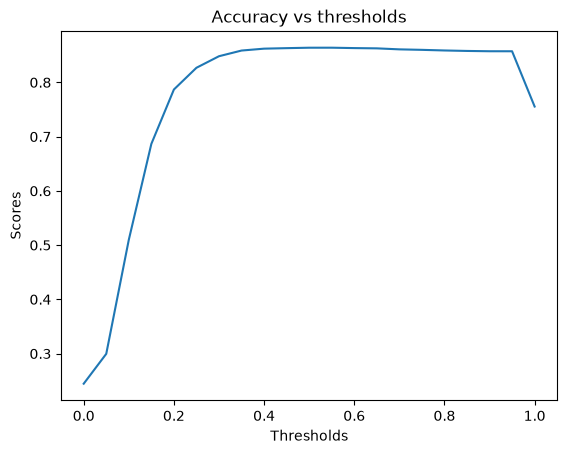

In [22]:
scores_only = [s[0] for s in scores]
plt.plot(thresholds, scores_only)
plt.xlabel('Thresholds')
plt.ylabel('Scores')
plt.title('Accuracy vs thresholds')

### Confusion matrix for base model

In [23]:
actual_positive = (y_val == 1)
actual_negative = (y_val == 0)
predict_positive = (y_val_pred >= best_t)
predict_negative = (y_val_pred < best_t)

tp = (predict_positive & actual_positive).sum()
tn = (predict_negative & actual_negative).sum()
fp = (predict_positive & actual_negative).sum()
fn = (predict_negative & actual_positive).sum()

confusion_matrix = np.array([
    [tn, fp],
    [fn, tp]
])

confusion_matrix

array([[21547,   171],
       [ 3740,  3289]])

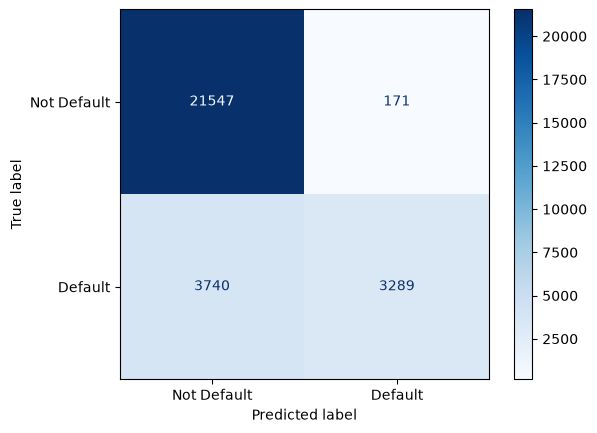

In [24]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_val, y_val_pred >= best_t)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Default', 'Default'])
disp.plot(cmap='Blues')


### Precission, Recall and F1 score

In [25]:
precision = tp / (tp+fp)
recall = tp/ (tp + fn)
precision, recall

(np.float64(0.9505780346820809), np.float64(0.4679186228482003))

In [26]:
from sklearn.metrics import precision_score, recall_score, classification_report


precision_score(y_val, y_val_pred >= best_t)
recall_score(y_val, y_val_pred >= best_t)

print(classification_report(y_val, y_val_pred >= best_t, target_names=['No Default', 'Default']))

              precision    recall  f1-score   support

  No Default       0.85      0.99      0.92     21718
     Default       0.95      0.47      0.63      7029

    accuracy                           0.86     28747
   macro avg       0.90      0.73      0.77     28747
weighted avg       0.88      0.86      0.85     28747



### ROC-AUC 

0.8377581498332898

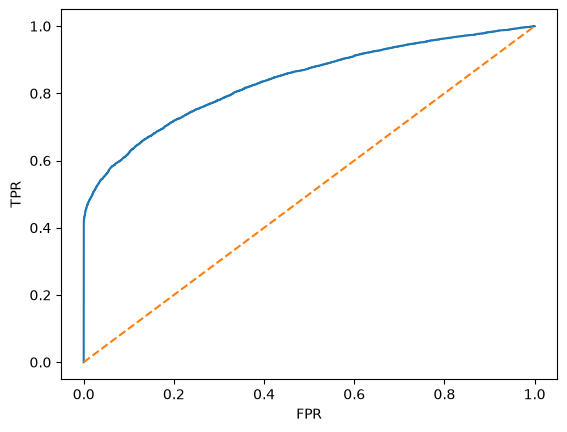

In [27]:
from sklearn.metrics import roc_auc_score, roc_curve
fpr, tpr, thresholds = roc_curve(y_val, y_val_pred)
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.plot(fpr, tpr, label='Model')
plt.plot([0, 1], [0, 1], linestyle='--', label='Random')
roc_auc_score(y_val, y_val_pred)

# Cross Validation and hyperparameter tuning

In [ ]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

# Properly separated param grid so l1_ratio ONLY applies to elasticnet
param_grid = [
    # Grid 1: liblinear (Fast, L1 & L2)
    {
        'solver': ['liblinear'],
        'penalty': ['l1', 'l2'],
        'C': np.logspace(-3, 3, 15)
    },
    # Grid 2: SAGA (L1 & L2 only)
    {
        'solver': ['saga'],
        'penalty': ['l1', 'l2'],
        'C': np.logspace(-3, 3, 15)
    },
    # Grid 3: SAGA (ElasticNet only - l1_ratio applied exclusively here)
    {
        'solver': ['saga'],
        'penalty': ['elasticnet'],
        'C': np.logspace(-3, 3, 10),
        'l1_ratio': [0.2, 0.5, 0.8]
    },
    # Grid 4: LBFGS (L2 & None)
    {
        'solver': ['lbfgs'],
        'penalty': ['l2', None],
        'C': np.logspace(-3, 3, 15)
    }
]

grid_search = GridSearchCV(
    estimator=LogisticRegression(max_iter=3000, random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train, y_train)

In [49]:
print("Best Hyperparameters:", grid_search.best_params_)
print(f"Best 5-Fold CV ROC-AUC: {grid_search.best_score_:.5f}")

Best Hyperparameters: {'C': np.float64(1000.0), 'penalty': 'l1', 'solver': 'liblinear'}
Best 5-Fold CV ROC-AUC: 0.83462


In [50]:
best_model = grid_search.best_estimator_
y_val_pred = best_model.predict_proba(X_val)[:, 1]
val_roc_auc = roc_auc_score(y_val, y_val_pred)
val_roc_auc

0.8378116034120205

In [51]:
import joblib

joblib.dump(best_model, '../models/best_logistic_model.pkl')
print('Model Saved')

Model Saved


In [55]:
joblib.dump(scaler, '../models/scaler.pkl')
joblib.dump(encoder, '../models/encoder.pkl')

['../models/encoder.pkl']